In [1]:
import torch
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

seed = 42
sample_size = 2000 # number of proteins to sample from Interpro dataset
protein_df = pd.read_csv('../../data/domains_GO_data.csv')
protein_df = protein_df.drop('Unnamed: 0', axis=1)
protein_df = protein_df.sample(n=sample_size, random_state=seed)
protein_go_terms = [gt.split("'")[1] for gt in protein_df['Go_Annotations']]
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
protein_df['Go_Annotations'] = protein_go_terms
protein_df= protein_df[protein_df['Go_Annotations'].isin(term_ind_map)]
protein_term_index = [term_ind_map[t] for t in protein_df['Go_Annotations']]
protein_df['Go_term_index'] = protein_term_index

In [2]:
from transformers import AutoModelForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig
import torch
device = torch.device('cuda:0')

tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
config = AutoConfig.from_pretrained('facebook/esm2_t6_8M_UR50D')
model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t6_8M_UR50D').to(device)
model.eval()
print("Loaded BERT Model")

Loaded BERT Model


In [3]:
annotated_indices = []
domain_edges = []

for domains, seq in zip(protein_df['Domains'], protein_df['Sequence']):
    protein_indices = []
    edges = []
    domains = domains.split('-')
    for domain in domains:
        ranges = domain.split("(")[1].split(")")[0].split(";")
        for start_end in ranges:
            start, end = map(int, start_end.split("..."))
            edges.extend([start, end])
            indices = np.arange(start, end + 1)
            protein_indices.extend(indices)

    protein_indices = list(filter(lambda x: x < min(1024, len(seq)), protein_indices))
    annotated_indices.append(protein_indices)
    edges = list(filter(lambda x: x < min(1024, len(seq)), edges))
    domain_edges.append(edges)
    

protein_df['AnnotatedIndices'] = annotated_indices
protein_df['DomainEdges'] = domain_edges
protein_df = protein_df[protein_df['AnnotatedIndices'].map(len) > 0] # only proteins with indices at this point can remain 

In [4]:
protein_df

,UniProt_ID,Interpro_ID,Domains,Sequence,Go_Annotations,Go_term_index,AnnotatedIndices,DomainEdges
73486,Q0AGX7,IPR001406,cd02570(5...243),MKIVLILEYDGRGYCGWQKQPDRISVQSRLESALSRIASSQIQVVA...,GO:0003723,11,"[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17...","[5, 243]"
9163,A4SD71,IPR002661,cd00520(6...184),MSVREVIQKNEAKLKKSIEAFQHEIASIRTGKATTALLDRVKVEAY...,GO:0006412,7,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1...","[6, 184]"
15394,A6VCH6,IPR005224,cd22359(11...234),MRFDPPLEEGRLLRRYKRFLADIESAGGERLTIHCPNTGSMLNCMS...,GO:0003677,13,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...","[11, 234]"
99531,Q5QS28,IPR048259,cd00284(9...206)-cd00290(207...354),MTNLRKTHPLMKIINHAFIDLPAPSNISAWWNFGSLLGICLIIQML...,GO:0009055,136,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...","[9, 206, 207, 354]"
103397,Q6A6Y6,IPR034964,cd09209(24...154),MSSRTTLGLSAPDLSGLDGSGLKVAVVAAQWHGTVMTGLLDGALRG...,GO:0000906,423,"[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 3...","[24, 154]"
...,...,...,...,...,...,...,...,...
64724,P51764,IPR005867,cd09289(7...344),MTTTLQQRESASLWEQFCQWITSTNNRLYVGWFGVIMIPTLLTATT...,GO:0009055,136,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[7, 344]"
92733,Q49XX3,IPR001059,cd04470(66...126)-cd05794(129...184),MISVNDFKTGLTISVDNGIWKVLDFQHVKPGKGSAFVRSKLRNLRT...,GO:0003746,86,"[66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 7...","[66, 126, 129, 184]"
106018,Q6LV59,IPR000146,cd00354(21...331),MPNMKTLGEFIVEKQNDFPHASGDLSSLLGSIKLAAKIVNREINKA...,GO:0016791,413,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...","[21, 331]"
67254,P63988,IPR022880,cd03586(10...345),MPTAAPRWILHVDLDQFLASVELLRHPELAGLPVIVGGNGDPTEPR...,GO:0003887,230,"[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...","[10, 345]"


In [5]:
import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
def protein_iterator():
     for i, pid, iid, domains, seq, goterm, go_ind, annot_ind, domain_edges in protein_df.itertuples():
          inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
          yield {'prot_id': pid, 'annot_ind': annot_ind, 'go_ind': go_ind, 'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}
seq_len = torch.LongTensor([len(r['seq']) for r in protein_iterator()])

# Get top tokens

In [6]:
mask_l = []
for r in protein_iterator():
    m = torch.zeros(1024, dtype=bool)
    m[1:len(r['seq'])+1] = True
    mask_l.append(m)
protein_mask = torch.stack(mask_l)

In [7]:
def mask_seq(seq_ind, attention_mask, mask_token, residue_coverage=6, mut_per=0.15):
    device = seq_ind.device
    seq_len = attention_mask.sum()-1
    mut_count = torch.floor(seq_len*mut_per).int().item()
    total_muts = (torch.floor(seq_len*residue_coverage/mut_count)*mut_count).int().item()

    mut_inds = (torch.randperm(total_muts).reshape(-1, mut_count).to(device) % seq_len) + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)

    batch = torch.tile(seq_ind, (mut_inds.shape[0], 1))
    batch[batch_inds, mut_inds] = mask_token
    return batch, batch_inds, mut_inds

In [9]:
device = torch.device('cuda:0')

bert_distr_l = []
with torch.no_grad():
    for i, r in enumerate(protein_iterator()):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        residue_coverage = 6
        seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
        bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
        mut_distr = torch.softmax(bert_pred.logits, dim=2)
        N, L, T = bert_pred.logits.shape
        bert_distr = torch.zeros(L, T, device=device)
        for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
            bert_distr[ti, :] += mut_distr[bi, ti, :]
        bert_distr /= residue_coverage
        bert_distr_l.append(bert_distr.cpu())
        if(i % 3 == 0):
            print(f"{100*i/len(protein_go_terms)}")

0.0
0.15
0.3


KeyboardInterrupt: 

In [28]:
# import pickle
# with open('/home/andrew/GO_interp/data/domains_2000_bert_distr.pkl', 'wb') as f:
#     pickle.dump(bert_distr_l, f)

In [10]:
import pickle

with open('/home/andrew/GO_interp/data/domains_2000_bert_distr.pkl', 'rb') as f:
    bert_distr_l = pickle.load(f)

In [12]:
bert_distr = torch.stack(bert_distr_l)
print(bert_distr.shape)
bert_attr = torch.nan_to_num((torch.log(bert_distr)*bert_distr).sum(axis=2), 0) #Negative entropy of residue positions
bert_attr = bert_attr - 1e9*(~protein_mask)
bert_attr.shape

torch.Size([1998, 1024, 33])


torch.Size([1998, 1024])

In [10]:
bert_attr

tensor([[-1.0000e+09, -1.4040e-01, -2.7226e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -8.5126e-01, -2.5895e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -3.7613e-01, -2.6914e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        ...,
        [-1.0000e+09, -4.9701e-01, -2.6787e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -2.1617e-01, -2.4347e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -3.5150e-01, -2.6272e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09]])

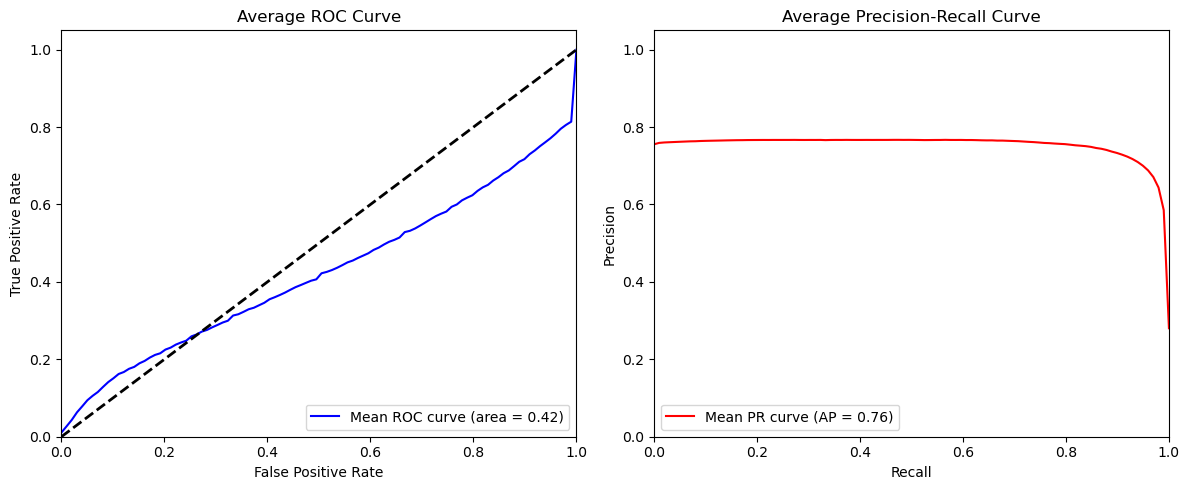

(0.4219637576000622, 0.7571350003912316)

In [11]:
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve

def roc_and_precision(attributions, annotated_indices, seq_len):
    all_fpr = []
    all_tpr = []
    all_prec = []
    all_rec = []
    roc_auc_scores = []
    pr_auc_scores = []
    
    for attr, annot, length in zip(attributions, annotated_indices, seq_len):
        longest = attributions.shape[1]
        if length > longest:
            length = longest - 1 
            
        valid_attr = attr[1:length+1] #skip first and skip padding 
        annot = np.array(annot) - 1
        labels = [1 if i in annot else 0 for i in range(length)]

        if np.sum(labels) == 0:
            continue

        fpr, tpr, _ = roc_curve(labels, valid_attr)
        roc_auc = auc(fpr, tpr)
        all_fpr.append(fpr)
        all_tpr.append(tpr)
        roc_auc_scores.append(roc_auc)

        precision, recall, _ = precision_recall_curve(labels, valid_attr)
        pr_auc = average_precision_score(labels, valid_attr)
        all_prec.append(precision)
        all_rec.append(recall)
        pr_auc_scores.append(pr_auc)
    
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    mean_recall = np.linspace(0, 1, 100)
    mean_precision = np.mean([np.interp(mean_recall[::-1], recall[::-1], precision[::-1]) for precision, recall in zip(all_prec, all_rec)], axis=0)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC curve (area = {mean_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Average ROC Curve')
    plt.legend(loc="lower right")
    
    plt.subplot(1, 2, 2)
    plt.plot(mean_recall, mean_precision, color='r', label=f'Mean PR curve (AP = {np.mean(pr_auc_scores):.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Average Precision-Recall Curve')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()
    
    return np.mean(roc_auc_scores), np.mean(pr_auc_scores)

roc_and_precision(bert_attr, protein_df["AnnotatedIndices"], seq_len)

In [13]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    token_attribution =  token_attribution # - 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        token_ranks = attribution_ranks[i, token_ind]
        ttr += torch.divide(1, token_ranks+1).sum()
        tct += token_ranks.shape[0]
    return ttr / tct
print(mean_reciprocal_rank(bert_attr, protein_df['AnnotatedIndices']))

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct
print(mean_percent_rank(bert_attr, seq_len, protein_df['AnnotatedIndices']))

tensor(0.0172)
tensor(0.4950)


In [13]:
def density_comparison(attributions, annotated_indices, seq_len):
    density_within = []
    density_outside = []
    for attr, annot, length in zip(attributions, annotated_indices, seq_len):
        annot = np.array(annot)
        within_domain = torch.mean(attr[annot])
        outside_domain = torch.mean(attr[~annot])
        density_within.append(within_domain)
        density_outside.append(outside_domain)
    
    avg_within = sum(density_within) / len(density_within)
    avg_outside = sum(density_outside) / len(density_outside)
    
    return avg_within, avg_outside

# normalize within 0 and 1 first 
bert_normalized = (bert_attr - bert_attr.min()) / (bert_attr.max() - bert_attr.min())
avg_within, avg_outside = density_comparison((bert_attr - bert_attr.min()) / (bert_attr.max() - bert_attr.min()), protein_df["AnnotatedIndices"], seq_len)
print(avg_within, avg_outside)

tensor(1.) tensor(0.0721)


In [14]:
bert_dx = np.abs(bert_attr[:,1:] - bert_attr[:,:-1])
# roc_and_precision(bert_dx, protein_df["DomainEdges"], seq_len)
bert_dx[:,0] = 0
bert_dx

tensor([[0.0000, 2.5822, 0.0361,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 1.7382, 0.1645,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 2.3153, 0.1582,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 2.1817, 0.1243,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 2.2185, 0.2420,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 2.2757, 0.1020,  ..., 0.0000, 0.0000, 0.0000]])

tensor([0., 1., 1.,  ..., 0., 0., 0.])

In [22]:
roc_and_precision(bert_dx, protein_df["DomainEdges"], seq_len)

ValueError: Found input variables with inconsistent numbers of samples: [1023, 1022]

In [28]:
bert_attr

tensor([[-1.0000e+09, -1.4040e-01, -2.7226e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -8.5126e-01, -2.5895e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -3.7613e-01, -2.6914e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        ...,
        [-1.0000e+09, -4.9701e-01, -2.6787e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -2.1617e-01, -2.4347e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09],
        [-1.0000e+09, -3.5150e-01, -2.6272e+00,  ..., -1.0000e+09,
         -1.0000e+09, -1.0000e+09]])

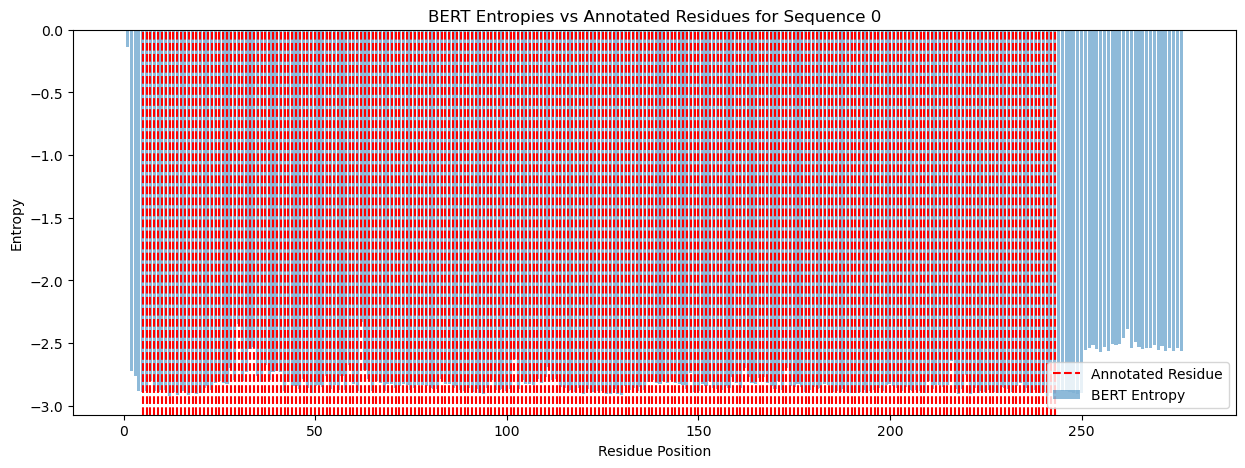

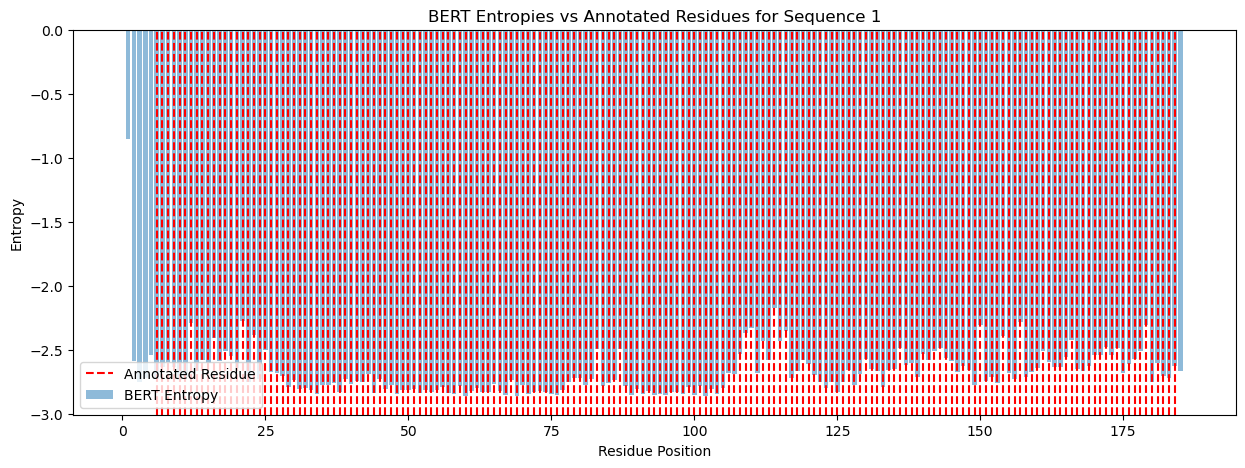

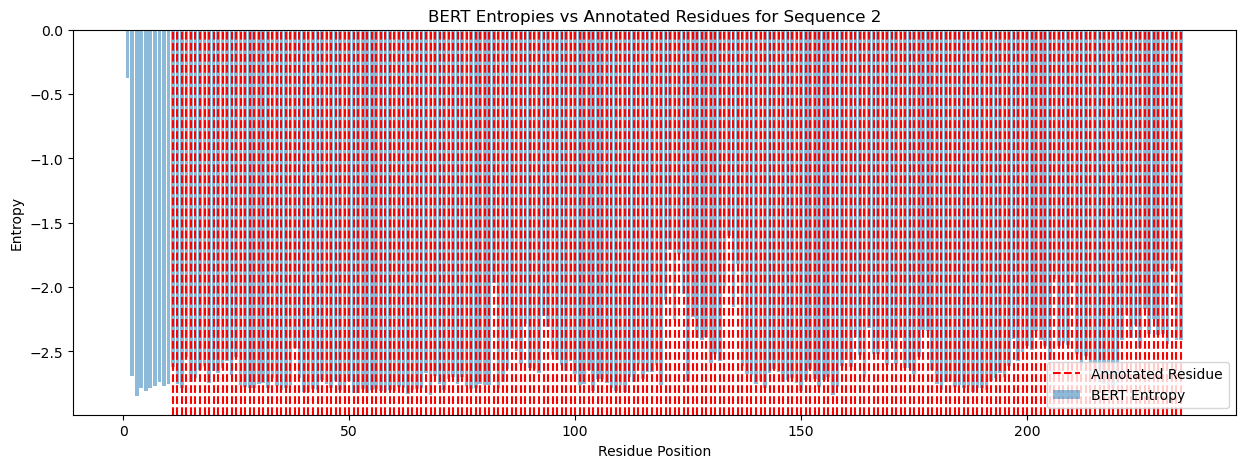

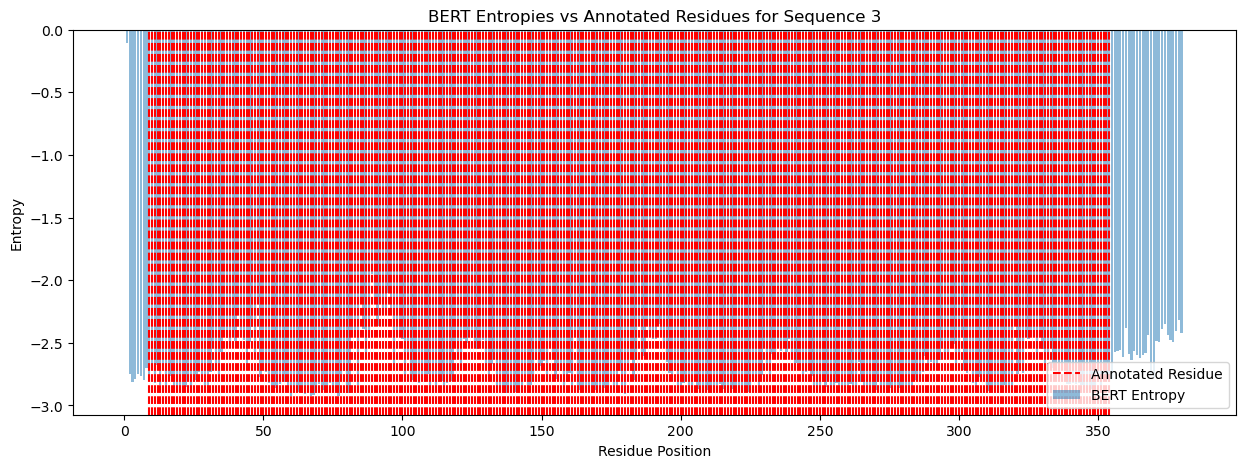

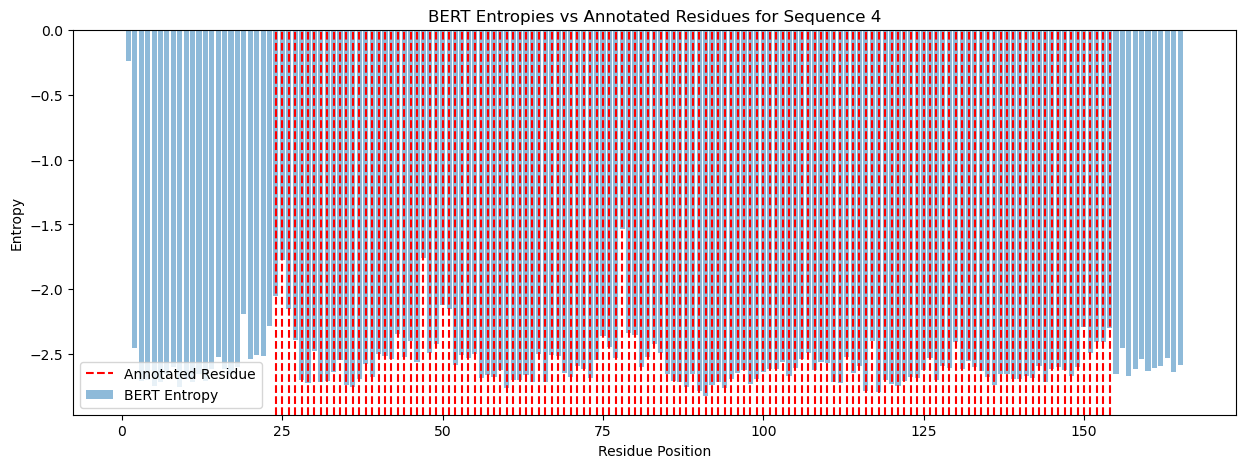

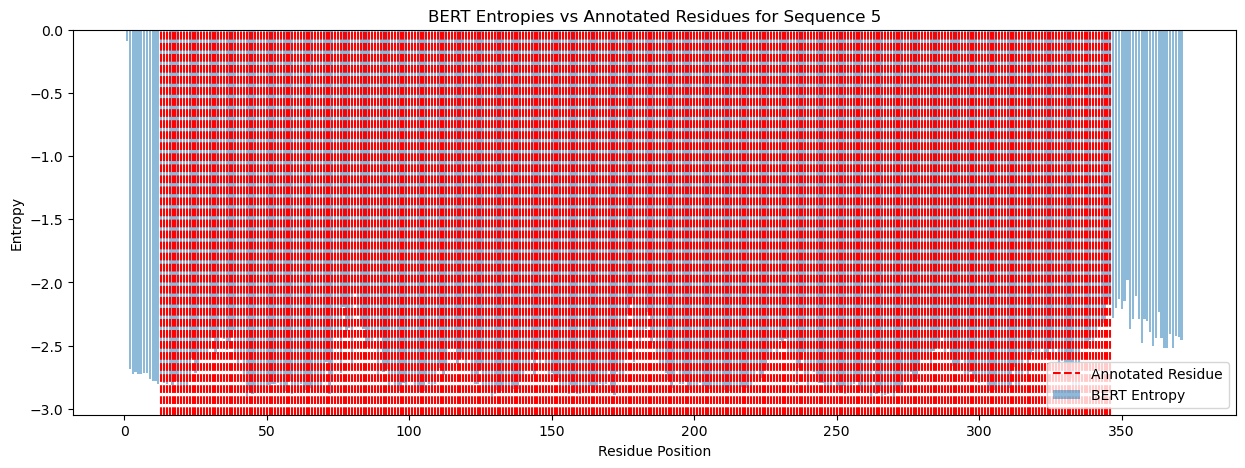

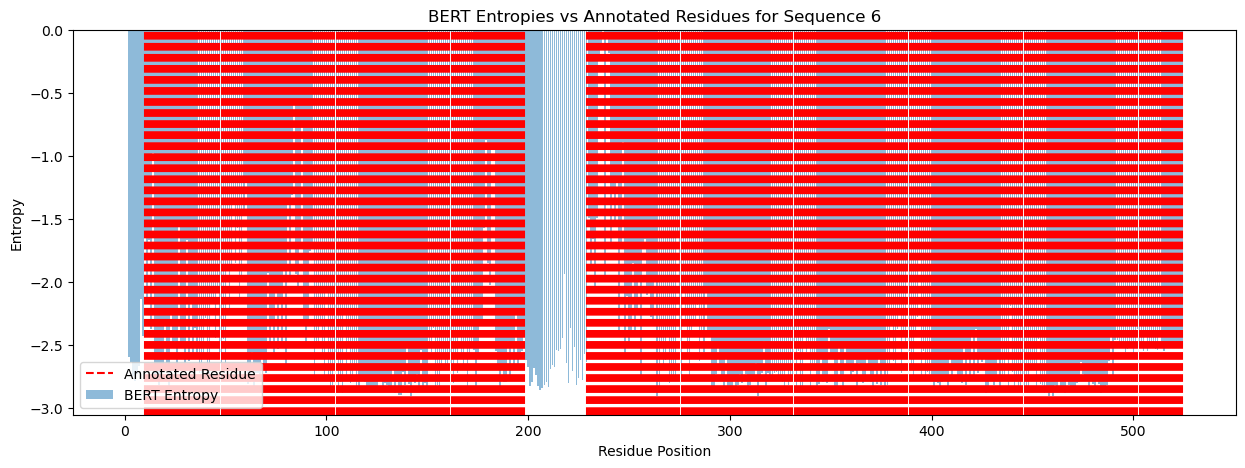

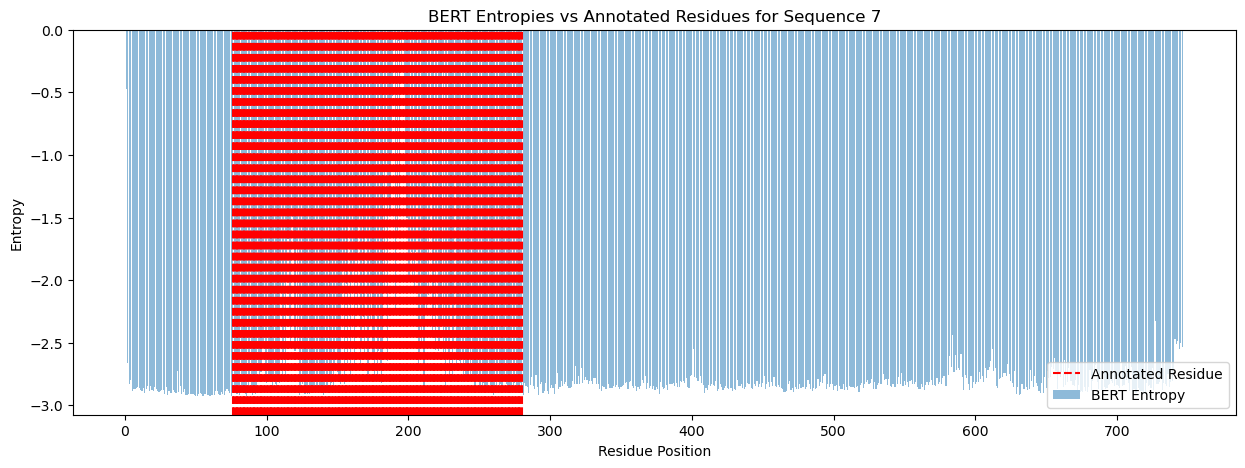

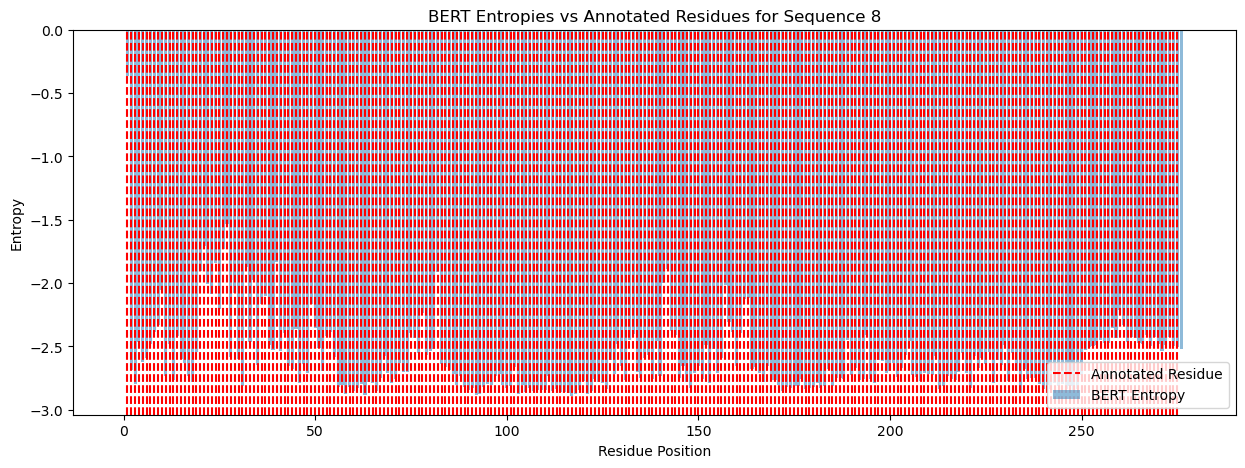

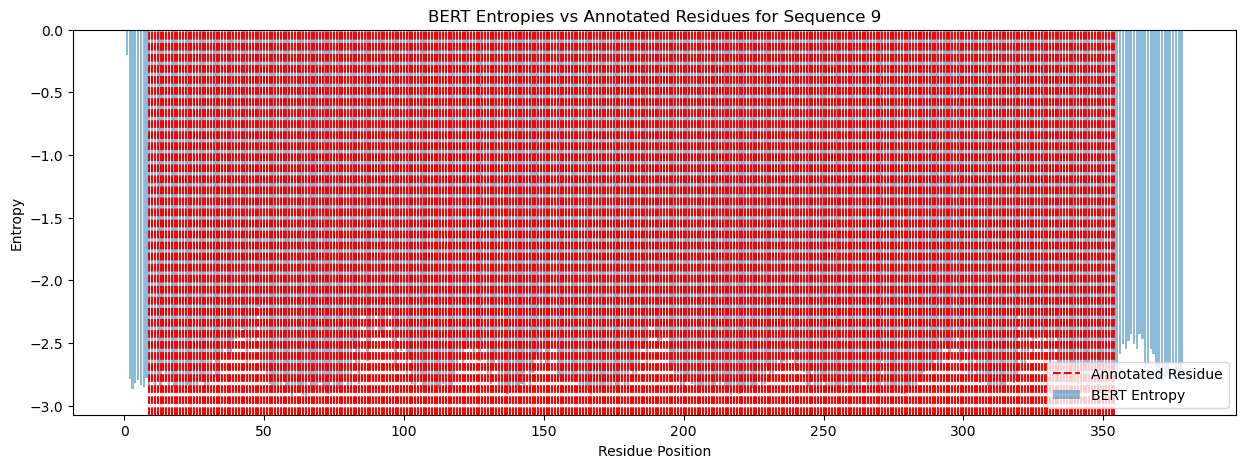

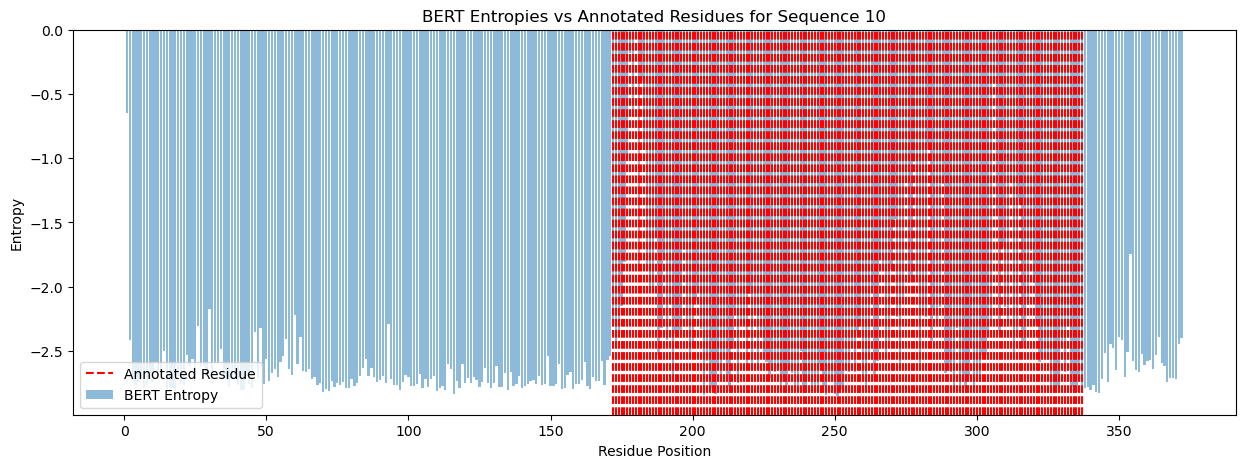

In [34]:
for sequence_index in np.arange(1000):
    sequence_length = len(protein_df.iloc[sequence_index]['Sequence'])
    bert_entropy = bert_attr[sequence_index, 1:sequence_length].cpu().numpy()
    annotated_indices = protein_df.iloc[sequence_index]['AnnotatedIndices']
    
    # print(bert_entropy)
    
    # print(annotated_indices)
    
    
    plt.figure(figsize=(15, 5))
    positions = np.arange(1, sequence_length)
    plt.bar(positions, bert_entropy, alpha=0.5, label='BERT Entropy')
    
    
    for idx in annotated_indices:
        plt.axvline(idx, color='red', linestyle='--', label='Annotated Residue' if idx == annotated_indices[0] else "")
    
    plt.xlabel('Residue Position')
    plt.ylabel('Entropy')
    plt.title(f'BERT Entropies vs Annotated Residues for Sequence {sequence_index}')
    plt.legend()
    plt.show()

    if sequence_index == 10:
        break

In [14]:
#Load fine-tuned GO model
import torch
import torch.nn as nn
device = torch.device('cuda:0')
from go_ml.models.bert_finetune import BERTFinetune
checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()
print("Model loaded")


class SingleGOModel(nn.Module):
    def __init__(self, model, go_idx):
        super().__init__()
        self.model = model
        self.go_idx = go_idx

    def forward(self, seq, mask, go_idx):
        return torch.sigmoid(self.model(seq, mask)[:, go_idx])
goind_model = SingleGOModel(model, 0)
goind_model.eval()
print("Model ready")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded
Model ready


In [15]:
from captum.attr import LayerActivation
# token_reference = TokenReferenceBase(reference_token_idx=0)
lact = LayerActivation(goind_model, goind_model.model.model.embeddings.word_embeddings)

def get_attributions_layer_act(lig, iter):
    attributions_lact_l = []
    for i, r in enumerate(iter):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        # reference_indices = token_reference.generate_reference(seq_ind.shape[1], device=device).unsqueeze(0)
        attributions_lact = lact.attribute(seq_ind, additional_forward_args=(mask.to(device), r['go_ind']))
        attributions_lact_l.append(attributions_lact.cpu())
        if(i % 50 == 0): 
            print(i)
    return attributions_lact_l
attributions_lact_l = get_attributions_layer_act(lact, protein_iterator())

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950


In [20]:
attributions = torch.stack(attributions_lact_l).squeeze().cpu()
sum_attributions = attributions.sum(dim=2)
magn_attributions = attributions.norm(dim=2)

mrr = mean_reciprocal_rank(sum_attributions, protein_df['AnnotatedIndices'])
mpr = mean_percent_rank(sum_attributions, torch.tensor([len(s) for s in protein_df['Sequence']]), list(protein_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

mrr = mean_reciprocal_rank(magn_attributions, protein_df['AnnotatedIndices'])
mpr = mean_percent_rank(magn_attributions, torch.tensor([len(s) for s in protein_df['Sequence']]), list(protein_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Mean-Reciprocal Rank 0.019967595115303993, Mean-Percentage Rank 0.49097728729248047
Mean-Reciprocal Rank 0.0015623003710061312, Mean-Percentage Rank 0.4917728900909424


In [16]:
from captum.attr import FeatureAblation
# token_reference = TokenReferenceBase(reference_token_idx=0)
lfa = FeatureAblation(goind_model)

def get_attributions_feature_abl(lfa, iter):
    attributions_lfa_l = []
    for i, r in enumerate(iter):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        attributions_lfa = lfa.attribute(seq_ind, additional_forward_args=(mask.to(device), r['go_ind']), perturbations_per_eval=16)
        attributions_lfa_l.append(attributions_lfa.cpu())
        if(i % 10 == 0):
            print(i)
    return attributions_lfa_l
attributions_lfa_l = get_attributions_feature_abl(lfa, protein_iterator())

0


KeyboardInterrupt: 

In [17]:
from captum.attr import LayerIntegratedGradients, TokenReferenceBase, visualization
token_reference = TokenReferenceBase(reference_token_idx=0)
lig = LayerIntegratedGradients(goind_model, goind_model.model.model.embeddings.word_embeddings)

def get_attributions(lig, iter):
    attributions_ig_l, delta_l = [], []
    for i, r in enumerate(iter):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        reference_indices = token_reference.generate_reference(seq_ind.shape[1], device=device).unsqueeze(0)
        attributions_ig, delta = lig.attribute(seq_ind, reference_indices, \
                                           n_steps=8, return_convergence_delta=True, 
                                           additional_forward_args=(mask.to(device), r['go_ind']))
        attributions_ig_l.append(attributions_ig.cpu())
        delta_l.append(delta)
        if(i % 10 == 0): 
            print(i)
    return attributions_ig_l, delta_l
attributions_l, delta_l = get_attributions(lig, protein_iterator())

OutOfMemoryError: CUDA out of memory. Tried to allocate 640.00 MiB. GPU 

In [ ]:
import pickle
attributions_ig = torch.stack(attributions_l).squeeze().cpu()
attributions_lact = torch.stack(attributions_lact_l).squeeze().cpu()
attributions_lfa = torch.stack(attributions_lfa_l).squeeze().cpu()
attr_dict = {'attributions_ig': attributions_ig, 'attributions_lact': attributions_lact, 'attributions_lfa': attributions_lfa}
with open('../../data/domains_attributions.pkl', 'wb') as f:
    pickle.dump(attr_dict, f)

In [ ]:
top_k_ind = torch.topk(bert_attr, k=75, dim=1, largest=True).indices - 1
#top_k_ind = torch.topk(bert_attr, k=50, dim=1, largest=True).indices - 1

# LIME interp on mutated sequences

In [ ]:
with open('/home/andrew/GO_interp/data/enzyme_mut_evals.pkl', 'rb') as f:
    mut_seq_dataset, model_evals = pickle.load(f)

In [ ]:
from scipy.sparse import csr_matrix
model_evals = csr_matrix(model_evals)

In [ ]:
go_term_statistics = np.asarray(model_evals.sum(axis=0)) / model_evals.shape[0]

In [ ]:
plt.plot(go_term_statistics.flatten())

In [ ]:
mut_sequences = mut_seq_dataset['seq']

In [ ]:
from go_ml.aa_params import aromatic_scale, pKs_scale, gravy_scale, protein_weight_scale
from sklearn.preprocessing import StandardScaler
import numpy as np

def residue_emb(sequence, key_ind):
    sequence_embeddings_list = []
    for ri in key_ind:
        r = sequence[ri]
        sequence_embeddings_list.append([aromatic_scale[r], pKs_scale[r], gravy_scale[r], protein_weight_scale[r]])
    sequence_embeddings = np.array(sequence_embeddings_list)
    return sequence_embeddings

seq_emb_l = []
for ed in enzyme_iterator():
    seq = ed['seq']
    key_ind = np.arange(len(seq))
    seq_emb = residue_emb(seq, key_ind)
    seq_emb_l.append(seq_emb)
res_emb = np.concatenate(seq_emb_l, axis=0)
residue_scaler = StandardScaler().fit(res_emb)

res_emb.shape

In [ ]:
import goatools
from goatools.obo_parser import GODag
godag = GODag('../go-basic.obo')
from goatools.godag.go_tasks import get_go2parents
optional_relationships = set()
go2parents_isa = get_go2parents(godag, optional_relationships)
from goatools.gosubdag.gosubdag import GoSubDag

gosubdag_r0 = GoSubDag(['GO:0018683'], godag, prt=None)
go_ancestors = gosubdag_r0.rcntobj.go2ancestors['GO:0018683']
go_ancestors.add('GO:0018683')


In [ ]:
go2parents_isa['GO:0018683']

In [ ]:
def get_parent_ind(go_ind):
    go_term = go_terms[go_ind]
    if(not go_term in go2parents_isa):
        return go_ind    
    parents = go2parents_isa[go_term]
    if(len(parents) == 0):
        return go_ind
    parent_inds = [term_ind_map[p] for p in parents if p in term_ind_map]
    if(len(parent_inds) == 0):
        return go_ind
    return parent_inds[0]

In [ ]:
def get_ancestor_ind(go_ind):
    go_term = go_terms[go_ind]
    if(not go_term in godag):
        return []
    gosubdag_r0 = GoSubDag([go_term], godag, prt=None)
    go_ancestors = gosubdag_r0.rcntobj.go2ancestors[go_term]
    go_ancestors.add(go_term)
    ancestor_ind = [term_ind_map[anc] for anc in go_ancestors if anc in term_ind_map]
    return ancestor_ind

In [ ]:
mut_residue_emb_l = []
for i, r in enumerate(enzyme_iterator()):
    key_ind = top_k_ind[i]
    prot_mut_l = mut_sequences[i*100:i*100+100]
    mut_residue_emb = []
    for pm in prot_mut_l:
        mut_residue_emb.append(residue_scaler.transform(residue_emb(pm, key_ind)))
    mut_residue_emb = np.array(mut_residue_emb)
    mut_residue_emb_l.append(mut_residue_emb)

In [ ]:
go_terms[20]
godag['GO:0005739'].depth

In [ ]:
print(mut_residue_emb[0].shape)

In [ ]:
from sklearn.linear_model import LinearRegression
lime_models = []
for i, r in enumerate(enzyme_iterator()):
    go_ind = r['go_ind']
    coef = np.zeros(mut_residue_emb[0].shape)
    mut_residue_emb = mut_residue_emb_l[i]
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    if(local_pred.sum()==0):
        go_ind = get_parent_ind(go_ind)
        local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    mut_inp = mut_residue_emb.reshape((100, -1))
    lime_model = LinearRegression()
    lime_model.fit(mut_inp, local_pred)
    coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
    lime_models.append(coef)

In [ ]:
lime_coef_attr = np.zeros((len(enzyme_df), 1024, 4))
for i, r in enumerate(enzyme_iterator()):
    key_ind = top_k_ind[i]
    lime_coef = lime_models[i]
    lime_coef_attr[i, key_ind+1, :] = lime_coef

In [ ]:
lime_abs_attr = torch.tensor(np.sum(np.abs(lime_coef_attr), axis=2)) - 1e9*(~enzyme_mask)
print(mean_percent_rank(lime_abs_attr, seq_len, enzyme_df['AnnotatedIndices']))
print(mean_reciprocal_rank(lime_abs_attr, enzyme_df['AnnotatedIndices']))

In [ ]:
nonkey_mask = np.ones(lime_abs_attr.shape, dtype=bool)
nonkey_mask[:, top_k_ind+1] = False
lime_abs_attr = lime_abs_attr + bert_attr*nonkey_mask
print(mean_percent_rank(lime_abs_attr, seq_len, enzyme_df['AnnotatedIndices']))

In [ ]:
print(bert_attr[0])

In [ ]:
b = bert_attr[0]
b[b< -1e3] = 0
b -= b.min()
print(b[top_k_ind[0]])

# is a reference so now bert_attr[0] is altered

In [ ]:
# figure 

# random GO terms
i = 0
r = next(enzyme_iterator())
seq = r['seq']
AA = [seq[n] for n in top_k_ind[i]]

true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1


correct_GO_model_coef = np.zeros((1, 1024, 4))
go_ind = r['go_ind']
go_term_correct = go_terms[go_ind]
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[i]
local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((100, -1))
lime_model = LinearRegression()
lime_model.fit(mut_inp, local_pred)
coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
correct_GO_model_coef[0, key_ind+1, :] = coef

random_go_ind = np.random.choice(1000, 1, replace=False)
go_ind = go_ind + random_go_ind
go_ind = go_ind[0]
go_term_other = go_terms[go_ind]
other_GO_model_coef = np.zeros((1, 1024, 4))
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[i]
local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((100, -1))
other_GO = LinearRegression()
other_GO.fit(mut_inp, local_pred)
coef += other_GO.coef_.reshape(mut_residue_emb[0].shape)
other_GO_model_coef[0, key_ind+1, :] = coef

print(np.abs(other_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1))
print(true_importance[top_k_ind[0]])

df=pd.DataFrame({
    'True': true_importance[top_k_ind[0]],
    'BERT': bert_attr[i][top_k_ind[i]] / torch.max(bert_attr[i]), 
    f'LIME Correct GO ({go_term_correct})': np.abs(correct_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1) / np.max(np.abs(correct_GO_model_coef[0]).sum(axis=-1)), 
    f'LIME Other GO ({go_term_other})': np.abs(other_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1) / np.max(np.abs(other_GO_model_coef[0]).sum(axis=-1))
}, index=AA)
df.plot.bar(rot=0)
plt.title(f"BERT and LIME for Protein: {r["prot_id"]}")
plt.figure(figsize=(15,8))
plt.show()

In [ ]:
# test run with just one protein
r = next(enzyme_iterator())
random_go_inds = np.random.choice(1000, 3, replace=False)
random_go_terms = [go_terms[i] for i in random_go_inds]
go_true = r['go_ind']
go_inds = [r['go_ind']] + random_go_inds
go_inds = np.append(go_true, go_inds)
i = 0

first_protein_models = []
for ind in go_inds:
    go_ind = ind
    coef = np.zeros(mut_residue_emb[0].shape)
    mut_residue_emb = mut_residue_emb_l[i]
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    if(local_pred.sum()==0):
        go_ind = get_parent_ind(go_ind)
        local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    mut_inp = mut_residue_emb.reshape((100, -1))
    lime_model = LinearRegression()
    lime_model.fit(mut_inp, local_pred)
    coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
    first_protein_models.append(coef)

lime_coef_attr = np.zeros((len(go_inds), 1024, 4))
for i, r in enumerate(go_inds):
    key_ind = top_k_ind[0]
    lime_coef = first_protein_models[i]
    lime_coef_attr[i, key_ind+1, :] = lime_coef

for i in range(len(go_inds)):
    sum = np.abs(lime_coef_attr[i]).sum(axis=-1)
    print(sum[annotated_indices[0]])


plt.plot(np.abs(lime_coef_attr[0]).sum(axis=-1), label='Magnitude Importances')
for i in range(1, len(go_inds)):
    go_term_label = f'Other GO Term{i}'
    plt.plot(np.abs(lime_coef_attr[i]).sum(axis=-1), label=go_term_label)
true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1

plt.legend()
plt.show()

In [ ]:
# this is for 1000 samples

from sklearn.linear_model import LinearRegression

with open('/home/andrew/GO_interp/data/first_enzyme_mut_evals.pkl', 'rb') as f:
    mut_seq_dataset, model_evals = pickle.load(f)

r = next(enzyme_iterator())

model_evals = csr_matrix(model_evals)
mut_sequences = mut_seq_dataset['seq']

mut_residue_emb_l = []
key_ind = top_k_ind[0]
prot_mut_l = mut_sequences  
mut_residue_emb = []
for pm in prot_mut_l:
    mut_residue_emb.append(residue_scaler.transform(residue_emb(pm, key_ind)))
mut_residue_emb = np.array(mut_residue_emb)
mut_residue_emb_l.append(mut_residue_emb)



first_protein_coef = np.zeros((1, 1024, 4))
go_ind = r['go_ind']
go_term_correct = go_terms[go_ind]
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[0]
local_pred = model_evals[:, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[:, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((1000, -1))
lime_model = LinearRegression()
lime_model.fit(mut_inp, local_pred)
coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
first_protein_coef[0, key_ind+1, :] = coef

mag = np.abs(first_protein_coef[0]).sum(axis=-1)
true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1

plt.plot(mag)
plt.plot(true_importance)

print(mag[true_importance == 1])

In [ ]:
from sklearn.linear_model import LinearRegression

with open('/home/andrew/GO_interp/data/first_enzyme_5000_mut_evals.pkl', 'rb') as f:
    mut_seq_dataset, model_evals = pickle.load(f)

r = next(enzyme_iterator())

model_evals = csr_matrix(model_evals)
mut_sequences = mut_seq_dataset['seq']

mut_residue_emb_l = []
key_ind = top_k_ind[0]
prot_mut_l = mut_sequences  
mut_residue_emb = []
for pm in prot_mut_l:
    mut_residue_emb.append(residue_scaler.transform(residue_emb(pm, key_ind)))
mut_residue_emb = np.array(mut_residue_emb)
mut_residue_emb_l.append(mut_residue_emb)


r = next(enzyme_iterator())
first_protein_coef = np.zeros((1, 1024, 4))
go_ind = r['go_ind']
go_term_correct = go_terms[go_ind]
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[0]
local_pred = model_evals[:, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[:, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((5000, -1))
lime_model = LinearRegression()
lime_model.fit(mut_inp, local_pred)
coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
first_protein_coef[0, key_ind+1, :] = coef

mag = np.abs(first_protein_coef[0]).sum(axis=-1)
true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1

plt.plot(mag)
plt.plot(true_importance)

print(mag[true_importance == 1])

In [ ]:
# finding best GO

r = next(enzyme_iterator())
random_go_inds = np.random.choice(1000, 100, replace=False)
random_go_terms = [go_terms[i] for i in random_go_inds]
go_true = r['go_ind']
go_inds = [r['go_ind']] + random_go_inds
go_inds = np.append(go_true, go_inds)
i = 0

first_protein_models = []
for ind in go_inds:
    go_ind = ind
    coef = np.zeros(mut_residue_emb[0].shape)
    mut_residue_emb = mut_residue_emb_l[i]
    local_pred = model_evals[:, go_ind].toarray().flatten()
    if(local_pred.sum()==0):
        go_ind = get_parent_ind(go_ind)
        local_pred = model_evals[:, go_ind].toarray().flatten()
    mut_inp = mut_residue_emb.reshape((5000, -1))
    lime_model = LinearRegression()
    lime_model.fit(mut_inp, local_pred)
    coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
    first_protein_models.append(coef)

lime_coef_attr = np.zeros((len(go_inds), 1024, 4))
for i, r in enumerate(go_inds):
    key_ind = top_k_ind[0]
    lime_coef = first_protein_models[i]
    lime_coef_attr[i, key_ind+1, :] = lime_coef

sums = np.array([np.abs(lime_coef_attr[i]).sum(axis=-1) for i in range(len(go_inds))])

top_ten_indices = np.argsort(-sums.sum(axis=1))[:10] 
top_ten_go_inds = [go_inds[i] for i in top_ten_indices]

for ind in top_ten_go_inds:
    print(ind == go_true or go_true in get_ancestor_ind(ind) or ind in get_ancestor_ind(go_true)) 
    
print(top_ten_go_inds)
print(go_true)

In [ ]:
protein_number = 40

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

labels = ['Aromaticity', 'pKa', 'Hydrophobicity', 'Molecular Weight']

for i, label in enumerate(labels):
    ax[0].plot(lime_coef_attr[protein_number][:, i], label=label)
    
ax[1].plot(np.abs(lime_coef_attr[protein_number]).sum(axis=-1), label='LIME Magnitude Importances')
true_importance = np.zeros(1024)
true_importance[annotated_indices[protein_number]] = 1
ax[0].plot(true_importance, label='Annotated Residues', color='C5')
ax[1].plot(true_importance, label='Annotated Residues', color='C5')
ax[1].set_xlim(0, 350) 
ax[0].set_xlim(0, 350) 
ax[0].legend()
ax[1].legend()
plt.show()

In [ ]:
enzyme_sample = list(enzyme_iterator())[37]

In [ ]:
import torch
import numpy as np

def mutate(seq, lambda_=15):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    mut_seq = np.array(list(seq))
    num_changes = np.random.poisson(lambda_)
    indices_to_change = np.random.choice(len(seq), num_changes, replace=False)
    mut_seq[indices_to_change] = np.random.choice(list(amino_acids), num_changes)
    mut_seq = ''.join(mut_seq)
    return mut_seq, num_changes

def mutate_ind(seq, key_ind, lambda_=15):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    mut_seq = np.array(list(seq))
    num_changes = np.random.poisson(lambda_)
    indices_to_change = np.random.choice(len(key_ind), num_changes, replace=False)
    mut_seq[key_ind[indices_to_change]] = np.random.choice(list(amino_acids), num_changes)
    mut_seq = ''.join(mut_seq)
    return mut_seq, num_changes

def mut_batch(prot_id, seq, key_ind, lambda_=15, batch_size=100):
    mut_seq = [mutate_ind(seq, key_ind, lambda_=lambda_)[0] for _ in range(batch_size)]
    inputs = tokenizer.batch_encode_plus(mut_seq, add_special_tokens=True, padding='max_length',
                    truncation=True, return_attention_mask=True, max_length=1024) 
    return {'seq': mut_seq, 'prot_id': [prot_id]*batch_size, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

In [ ]:
mut_batch_d = mut_batch(enzyme_sample['prot_id'], enzyme_sample['seq'], np.arange(1, 25), lambda_=6, batch_size=10)
seq_id = torch.LongTensor(mut_batch_d['seq_ind'])[:, :50]

In [ ]:
(seq_id[6] != seq_id[9]).sum()

In [ ]:

mut_seq_dl = []
for i, r in enumerate(enzyme_iterator()):
    mut_seq_batch = mut_batch(r['prot_id'], r['seq'], top_k_ind[i, :min(75, len(r['seq']))], lambda_=15, batch_size=5)
    mut_seq_dl.append(mut_seq_batch)

def collate_dict(data_dict_l):
    ex = data_dict_l[0]
    dd = {}
    for k, v in ex.items():
        if(type(v) is torch.Tensor):
            dd[k] = torch.cat([data_dict_l[i][k] for i in range(len(data_dict_l))])
        else:
            dd[k] = []
            for i in range(len(data_dict_l)):
                dd[k].extend(data_dict_l[i][k])              
    return dd
mut_seq_dataset = collate_dict(mut_seq_dl)

In [ ]:
import torch
import torch.nn as nn
import pickle
from go_ml.models.bert_finetune import BERTFinetune
device = torch.device('cuda:1')

checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
# with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
#     hparams = pickle.load(f)
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()
# seq_ind, mask =  torch.tensor(enzyme_sample['seq_ind']).to(device), torch.BoolTensor(enzyme_sample['mask']).to(device)
seq_ind = torch.tensor(mut_seq_dataset['seq_ind'][:10]).to(device)
mask = torch.BoolTensor(mut_seq_dataset['mask'][:10]).to(device)
pred = model(seq_ind, mask)

In [ ]:
from scipy.sparse import csr_array, vstack
def get_evals(model, mut_seq_dataset, batch_size=40):
    d = mut_seq_dataset
    device = model.device
    eval_l = []
    with torch.no_grad():
        for i in range(0, len(d['seq_ind']), batch_size):
            seq_ind, mask =  torch.tensor(d['seq_ind'][i:i+batch_size]).to(device), torch.BoolTensor(d['mask'][i:i+batch_size]).to(device)
            logit_preds = model.forward(seq_ind, mask)
            logit_preds = logit_preds * (logit_preds > -9)
            sparse_preds = csr_array(logit_preds.cpu().numpy())
            eval_l.append(sparse_preds)
            if(i % (2*batch_size) == 0 and i > 0):
                print(f"{100*i/len(d['seq_ind'])}% Eval")
                break
    eval_results = vstack(eval_l)
    return eval_results
model_evals = get_evals(model, mut_seq_dataset, batch_size=40)


In [ ]:
enzyme_sample = list(enzyme_iterator())[37]
print(enzyme_sample)

In [ ]:
import goatools
from goatools.obo_parser import GODag
from goatools.gosubdag.gosubdag import GoSubDag
from goatools.godag.go_tasks import get_go2parents

godag = GODag('../go-basic.obo')
optional_relationships = set()
go2parents_isa = get_go2parents(godag, optional_relationships)
gosubdag_r0 = GoSubDag(['GO:0018683'], godag, prt=None)
go_ancestors = gosubdag_r0.rcntobj.go2ancestors['GO:0018683']
go_ancestors.add('GO:0018683')
print(go_ancestors)
ancestor_ind = [term_ind_map[anc] for anc in go_ancestors]
print(ancestor_ind)
print(pred[0, ancestor_ind])

In [ ]:
r = next(enzyme_iterator())
seq = r['seq']
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
mut_seq = np.array(list(seq))
num_changes = np.random.poisson(15)
num_changes = min(num_changes, len(key_ind))
indices_to_change = np.random.choice(len(key_ind), num_changes, replace=False)
print(num_changes)
if num_changes == 1:
    indices_to_change = indices_to_change[0]
    mut_seq[key_ind[indices_to_change]] = np.random.choice(list(amino_acids)) 
else:
    mut_seq[key_ind[indices_to_change]] = np.random.choice(list(amino_acids), num_changes)
mut_seq = ''.join(mut_seq)
